In [1]:
#Step 1: Text Preprocessing
import os
import re

STOPWORDS = {
    "the", "is", "in", "and", "to", "of", "for", "on", "with", "as", "are", "a", "by", "this", "it", "from"
}

def preprocess(text):
    text = text.lower()
    tokens = re.findall(r"[a-z]+", text)
    tokens = [t for t in tokens if t not in STOPWORDS]
    return tokens

def load_documents(path="data"):
    documents = {}
    for file in os.listdir(path):
        if file.endswith(".txt"):
            with open(os.path.join(path, file), "r", encoding="utf-8") as f:
                documents[file] = preprocess(f.read())
    return documents

documents = load_documents()

for doc, tokens in documents.items():
    print(doc, "→", tokens)

doc1.txt → ['machine', 'learning', 'algorithms', 'widely', 'used', 'data', 'analysis', 'prediction', 'supervised', 'unsupervised', 'learning', 'techniques', 'common', 'modern', 'systems']
doc10.txt → ['conceptually', 'three', 'matrices', 'involved', 'graph', 'based', 'retrieval', 'system', 'tf', 'idf', 'matrix', 'term', 'weighting', 'adjacency', 'matrix', 'representing', 'graph', 'structure', 'normalized', 'transition', 'matrix', 'used', 'relevance', 'propagation']
doc100.txt → ['statistical', 'analysis', 'supports', 'hypothesis', 'testing', 'data', 'analytics', 'involves', 'extracting', 'insights', 'structured', 'unstructured', 'data', 'inverted', 'indexes', 'allow', 'efficient', 'term', 'based', 'searching', 'search', 'engines', 'rely', 'indexing', 'retrieval', 'models', 'process', 'large', 'document', 'collections']
doc101.txt → ['hehe']
doc11.txt → ['hehehehehe']
doc12.txt → ['test', 'document']
doc13.txt → ['test', 'document']
doc14.txt → ['graph', 'based', 'retrieval', 'test', 'd

In [2]:
# Step 2: TF-IDF Computation
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [" ".join(tokens) for tokens in documents.values()]
doc_names = list(documents.keys())
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)
terms = vectorizer.get_feature_names_out()

print("Number of documents:", tfidf_matrix.shape[0])
print("Number of terms:", tfidf_matrix.shape[1])

Number of documents: 101
Number of terms: 179


In [3]:
import pandas as pd

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=doc_names,
    columns=terms
)

tfidf_df.head()

,accuracy,across,activated,adjacency,advanced,algorithms,allow,allowing,analysis,analytics,...,used,useful,using,vector,visualization,volume,web,weighting,weights,widely
doc1.txt,0.0,0.0,0.0,0.000000,0.0,0.192561,0.000000,0.0,0.172420,0.000000,...,0.169921,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.206908
doc10.txt,0.0,0.0,0.0,0.194622,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.092842,0.0,0.0,0.0,0.0,0.0,0.0,0.194622,0.0,0.000000
doc100.txt,0.0,0.0,0.0,0.000000,0.0,0.000000,0.203397,0.0,0.152778,0.144315,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
doc101.txt,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
doc11.txt,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000


In [4]:
# Step 3: Term–Document Graph Construction
import networkx as nx

G = nx.Graph()
for doc in doc_names:
    G.add_node(doc, node_type="document")
for term in terms:
    G.add_node(term, node_type="term")
for doc_index, doc in enumerate(doc_names):
    for term_index, term in enumerate(terms):
        weight = tfidf_matrix[doc_index, term_index]
        if weight > 0:
            G.add_edge(doc, term, weight=weight)
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

list(G.edges(data=True))[:10]

Number of nodes: 280
Number of edges: 2164


[('doc1.txt', 'algorithms', {'weight': np.float64(0.19256060425483915)}),
 ('doc1.txt', 'analysis', {'weight': np.float64(0.17241989444118627)}),
 ('doc1.txt', 'common', {'weight': np.float64(0.38811065284118296)}),
 ('doc1.txt', 'data', {'weight': np.float64(0.10945440315194861)}),
 ('doc1.txt', 'learning', {'weight': np.float64(0.3303011282520081)}),
 ('doc1.txt', 'machine', {'weight': np.float64(0.20690842262960082)}),
 ('doc1.txt', 'modern', {'weight': np.float64(0.38811065284118296)}),
 ('doc1.txt', 'prediction', {'weight': np.float64(0.38811065284118296)}),
 ('doc1.txt', 'supervised', {'weight': np.float64(0.21519978196808054)}),
 ('doc1.txt', 'systems', {'weight': np.float64(0.14666983228478947)})]

In [5]:
#one document's connection 
doc = doc_names[0]
neighbors = G[doc]

for term, attrs in neighbors.items():
    print(term, "→", round(attrs["weight"], 3))

algorithms → 0.193
analysis → 0.172
common → 0.388
data → 0.109
learning → 0.33
machine → 0.207
modern → 0.388
prediction → 0.388
supervised → 0.215
systems → 0.147
techniques → 0.165
unsupervised → 0.388
used → 0.17
widely → 0.207


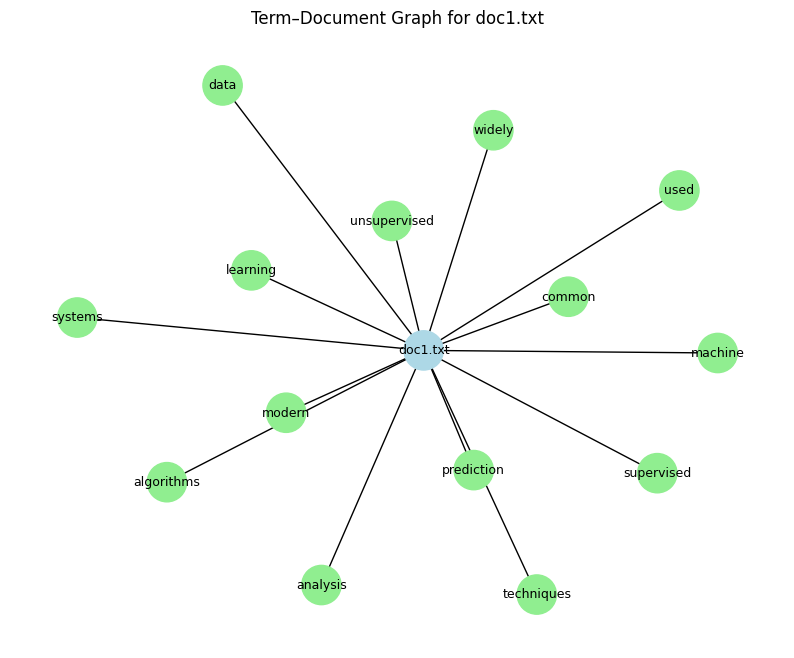

In [6]:
# Graph Visualization (Term–Document Subgraph)
import matplotlib.pyplot as plt

doc_to_visualize = doc_names[0]
nodes_to_draw = [doc_to_visualize] + list(G.neighbors(doc_to_visualize))
subG = G.subgraph(nodes_to_draw)
pos = nx.spring_layout(subG, seed=42)

plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(
    subG, pos,
    node_size=800,
    node_color=["lightblue" if n == doc_to_visualize else "lightgreen" for n in subG.nodes()]
)
nx.draw_networkx_edges(subG, pos)
nx.draw_networkx_labels(subG, pos, font_size=9)

plt.title(f"Term–Document Graph for {doc_to_visualize}")
plt.axis("off")
plt.show()

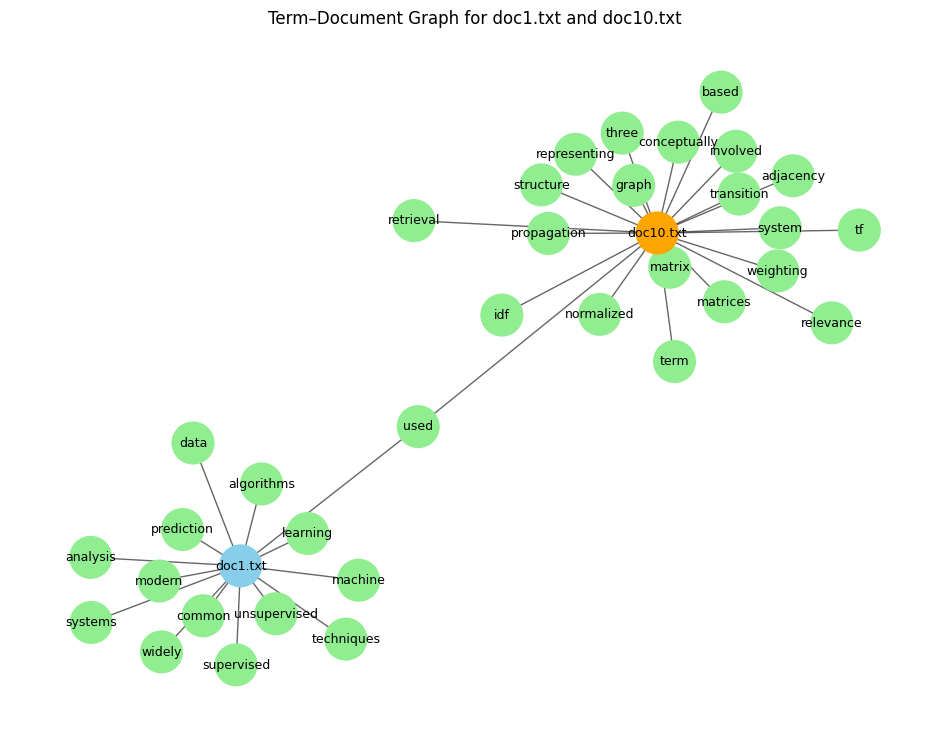

In [7]:
# Visualization of Two-Document Term–Document Subgraph
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
doc1 = doc_names[0]
doc2 = doc_names[1]

nodes_to_draw = set([doc1, doc2])
nodes_to_draw.update(G.neighbors(doc1))
nodes_to_draw.update(G.neighbors(doc2))

subG = G.subgraph(nodes_to_draw)
pos = nx.spring_layout(subG, seed=42)

plt.figure(figsize=(12, 9))
node_colors = []
for node in subG.nodes():
    if node == doc1:
        node_colors.append("skyblue")
    elif node == doc2:
        node_colors.append("orange")
    else:
        node_colors.append("lightgreen")

nx.draw_networkx_nodes(
    subG,
    pos,
    node_color=node_colors,
    node_size=900
)

nx.draw_networkx_edges(subG, pos, alpha=0.6)
nx.draw_networkx_labels(subG, pos, font_size=9)

plt.title(f"Term–Document Graph for {doc1} and {doc2}")
plt.axis("off")
plt.show()

In [8]:
# Step 4: Query Processing and Initial Relevance Vector
def process_query(query):
    return preprocess(query)

query = "graph based information retrieval"

query_terms = process_query(query)
print("Processed Query Terms:", query_terms)

Processed Query Terms: ['graph', 'based', 'information', 'retrieval']


In [9]:
relevance = {node: 0.0 for node in G.nodes()}

for term in query_terms:
    if term in G:
        relevance[term] = 1.0

activated = {k: v for k, v in relevance.items() if v > 0}
activated

{'based': 1.0, 'graph': 1.0, 'information': 1.0, 'retrieval': 1.0}

In [10]:
active_nodes = [n for n, v in relevance.items() if v > 0]
print("Active query nodes in graph:", active_nodes)

Active query nodes in graph: ['based', 'graph', 'information', 'retrieval']


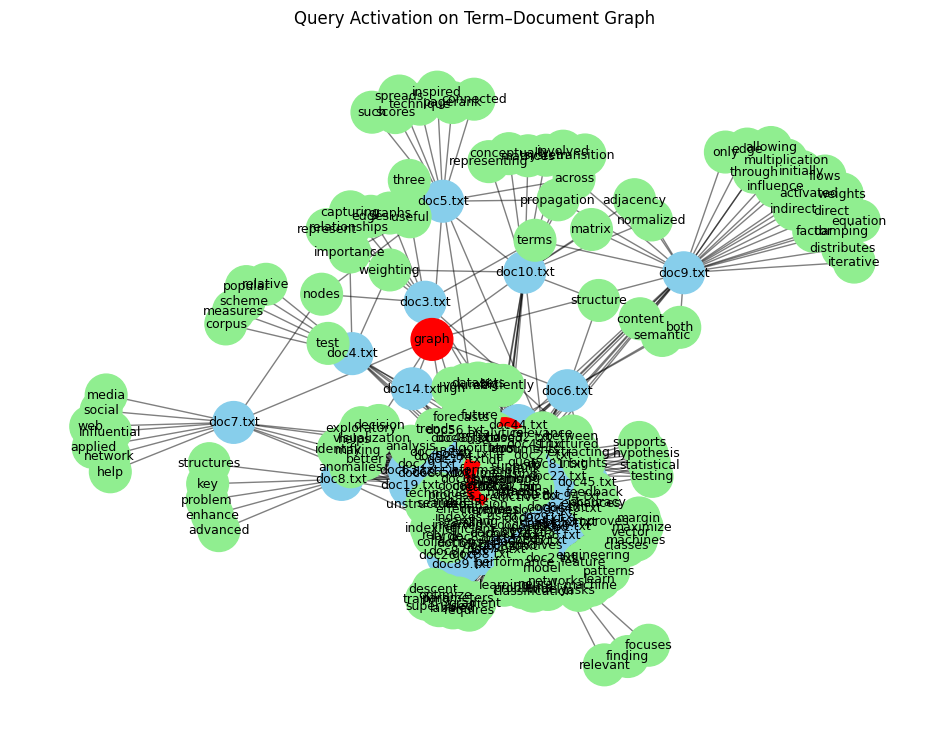

In [11]:
# Visualization of Query Activation on the Graph
import matplotlib.pyplot as plt

active_terms = [t for t in query_terms if t in G]
related_docs = set()
for term in active_terms:
    related_docs.update(G.neighbors(term))
nodes_to_draw = set(active_terms)
nodes_to_draw.update(related_docs)
for doc in related_docs:
    nodes_to_draw.update(G.neighbors(doc))
subG = G.subgraph(nodes_to_draw)
pos = nx.spring_layout(subG, seed=42)

plt.figure(figsize=(12, 9))

node_colors = []
for node in subG.nodes():
    if node in active_terms:
        node_colors.append("red")          
    elif node in doc_names:
        node_colors.append("skyblue")      
    else:
        node_colors.append("lightgreen")   

nx.draw_networkx_nodes(subG, pos, node_color=node_colors, node_size=900)
nx.draw_networkx_edges(subG, pos, alpha=0.5)
nx.draw_networkx_labels(subG, pos, font_size=9)

plt.title("Query Activation on Term–Document Graph")
plt.axis("off")
plt.show()

In [12]:
# Step 5: Relevance Propagation Algorithm
normalized_G = nx.Graph()

for node in G.nodes():
    normalized_G.add_node(node)

for node in G.nodes():
    neighbors = G[node]
    total_weight = sum(attrs["weight"] for _, attrs in neighbors.items())
    
    for neighbor, attrs in neighbors.items():
        if total_weight > 0:
            normalized_weight = attrs["weight"] / total_weight
            normalized_G.add_edge(node, neighbor, weight=normalized_weight)

In [13]:
def propagate_relevance(G, R0, alpha=0.85, iterations=20):
    R = R0.copy()
    
    for _ in range(iterations):
        new_R = {node: (1 - alpha) * R0.get(node, 0) for node in G.nodes()}
        
        for node in G.nodes():
            for neighbor, attrs in G[node].items():
                new_R[neighbor] += alpha * R[node] * attrs["weight"]
        
        R = new_R
    
    return R

In [14]:
final_relevance = propagate_relevance(
    normalized_G,
    relevance,
    alpha=0.85,
    iterations=20
)

In [15]:
# Get document relevance scores
doc_scores = {
    node: score
    for node, score in final_relevance.items()
    if node in doc_names
}

# Sort documents by relevance
ranked_docs = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)

ranked_docs

[('doc9.txt', np.float64(172554321.89174676)),
 ('doc10.txt', np.float64(13680493.956870101)),
 ('doc5.txt', np.float64(6352557.408116514)),
 ('doc3.txt', np.float64(3645664.8281954867)),
 ('doc6.txt', np.float64(2857683.302042082)),
 ('doc4.txt', np.float64(453586.45054975303)),
 ('doc7.txt', np.float64(297861.84867822763)),
 ('doc14.txt', np.float64(223589.3566687693)),
 ('doc8.txt', np.float64(165503.48317632734)),
 ('doc87.txt', np.float64(62483.05356712225)),
 ('doc51.txt', np.float64(60780.12727138834)),
 ('doc92.txt', np.float64(59834.214472708234)),
 ('doc27.txt', np.float64(55157.753231834766)),
 ('doc66.txt', np.float64(54915.187370504354)),
 ('doc43.txt', np.float64(53899.36428282396)),
 ('doc52.txt', np.float64(53899.36428282396)),
 ('doc35.txt', np.float64(53898.06231118315)),
 ('doc40.txt', np.float64(53570.118657183855)),
 ('doc83.txt', np.float64(53071.929706697774)),
 ('doc37.txt', np.float64(52794.585197442895)),
 ('doc22.txt', np.float64(50928.27660527019)),
 ('doc62

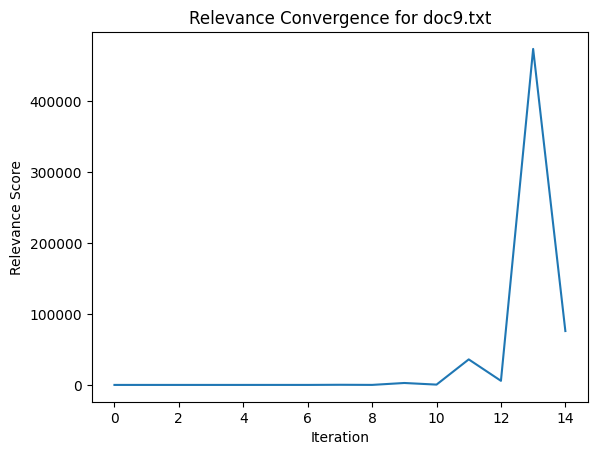

In [16]:
def propagate_with_history(G, R0, alpha=0.85, iterations=15):
    history = []
    R = R0.copy()
    
    for _ in range(iterations):
        history.append(R.copy())
        new_R = {node: (1 - alpha) * R0.get(node, 0) for node in G.nodes()}
        
        for node in G.nodes():
            for neighbor, attrs in G[node].items():
                new_R[neighbor] += alpha * R[node] * attrs["weight"]
        
        R = new_R
    
    return history

history = propagate_with_history(normalized_G, relevance)

import matplotlib.pyplot as plt

doc = ranked_docs[0][0] 
scores = [h[doc] for h in history]

plt.plot(scores)
plt.xlabel("Iteration")
plt.ylabel("Relevance Score")
plt.title(f"Relevance Convergence for {doc}")
plt.show()

In [17]:
# Step 6: Baseline Retrieval Using TF-IDF
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

query_vec = vectorizer.transform([" ".join(query_terms)])

# Compute cosine similarity
scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

tfidf_ranking = sorted(
    zip(doc_names, scores),
    key=lambda x: x[1],
    reverse=True
)

tfidf_ranking

print("TF-IDF Ranking:")
for doc, score in tfidf_ranking:
    print(doc, round(score, 4))

print("\nGraph-Based Ranking:")
for doc, score in ranked_docs:
    print(doc, round(score, 4))

TF-IDF Ranking:
doc14.txt 0.6285
doc8.txt 0.2799
doc6.txt 0.2743
doc10.txt 0.2711
doc3.txt 0.2385
doc92.txt 0.2274
doc93.txt 0.2086
doc91.txt 0.2023
doc56.txt 0.1935
doc27.txt 0.1769
doc43.txt 0.1727
doc52.txt 0.1727
doc45.txt 0.1718
doc83.txt 0.1684
doc2.txt 0.1683
doc94.txt 0.1636
doc65.txt 0.1634
doc50.txt 0.1619
doc81.txt 0.1584
doc35.txt 0.1536
doc42.txt 0.1524
doc37.txt 0.1516
doc48.txt 0.1509
doc85.txt 0.1509
doc7.txt 0.1478
doc21.txt 0.1394
doc87.txt 0.1388
doc84.txt 0.1375
doc5.txt 0.1365
doc69.txt 0.1349
doc68.txt 0.1349
doc51.txt 0.1347
doc58.txt 0.1343
doc86.txt 0.1301
doc9.txt 0.1295
doc19.txt 0.129
doc100.txt 0.1274
doc17.txt 0.126
doc4.txt 0.1206
doc62.txt 0.1103
doc44.txt 0.095
doc47.txt 0.0818
doc88.txt 0.0787
doc29.txt 0.0766
doc16.txt 0.076
doc61.txt 0.0756
doc26.txt 0.0751
doc46.txt 0.0737
doc49.txt 0.0698
doc74.txt 0.0695
doc63.txt 0.0653
doc89.txt 0.0562
doc66.txt 0.0425
doc40.txt 0.0414
doc22.txt 0.0399
doc53.txt 0.0396
doc32.txt 0.0382
doc80.txt 0.0378
doc73.txt